In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('SuperMarket Analysis.csv')

print("--- Initial Structural Check ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

--- Initial Structural Check ---
Total Rows: 1000, Total Columns: 17


In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [5]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [8]:
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [9]:
df['Date'] = pd.to_datetime(df['Date'])


In [10]:
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [12]:
cat_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Branch
Branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64

City
City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

Customer type
Customer type
Member    565
Normal    435
Name: count, dtype: int64

Gender
Gender
Female    571
Male      429
Name: count, dtype: int64

Product line
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

Payment
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


In [13]:
sns.set_theme(style="whitegrid")

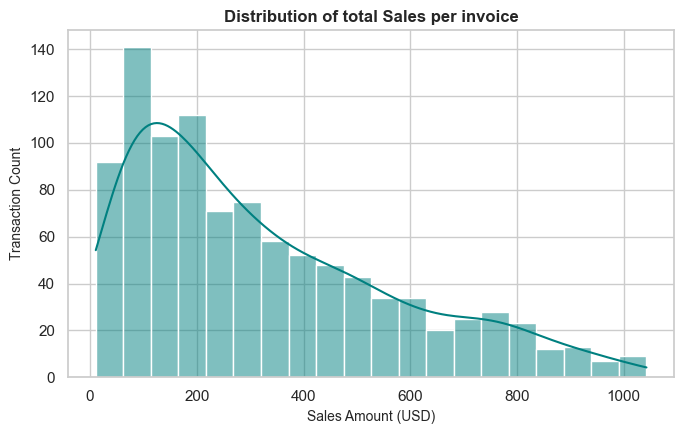

In [17]:
plt.figure(figsize=(7,4.5))

sns.histplot(df['Sales'], kde=True, color='teal',  bins=20)
plt.title('Distribution of total Sales per invoice', fontsize=12, fontweight='bold')
plt.xlabel('Sales Amount (USD)',fontsize=10)
plt.ylabel('Transaction Count', fontsize=10)
plt.tight_layout()
plt.savefig('save_distribution.png',dpi=300)
plt.show()
plt.close()

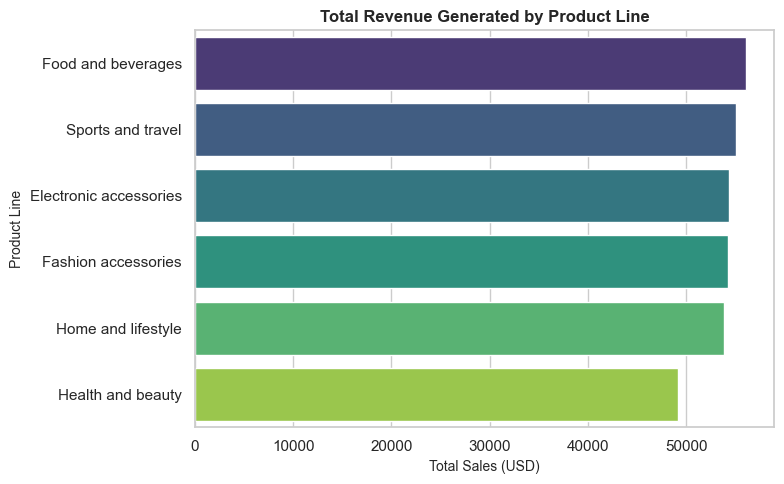

In [18]:
plt.figure(figsize=(8, 5))

product_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=product_sales, x='Sales', y='Product line', palette='viridis', hue='Product line', legend=False)
plt.title('Total Revenue Generated by Product Line', fontsize=12, fontweight='bold')
plt.xlabel('Total Sales (USD)', fontsize=10)
plt.ylabel('Product Line', fontsize=10)
plt.tight_layout()
plt.savefig('sales_by_product_line.png', dpi=300)
plt.show()
plt.close()

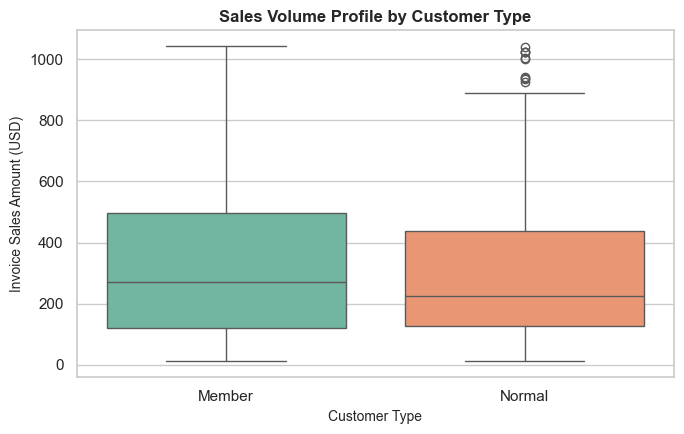

In [19]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x='Customer type', y='Sales', palette='Set2', hue='Customer type', legend=False)
plt.title('Sales Volume Profile by Customer Type', fontsize=12, fontweight='bold')
plt.xlabel('Customer Type', fontsize=10)
plt.ylabel('Invoice Sales Amount (USD)', fontsize=10)
plt.tight_layout()
plt.savefig('sales_by_cutomer_type.png', dpi=300)
plt.show()
plt.close()


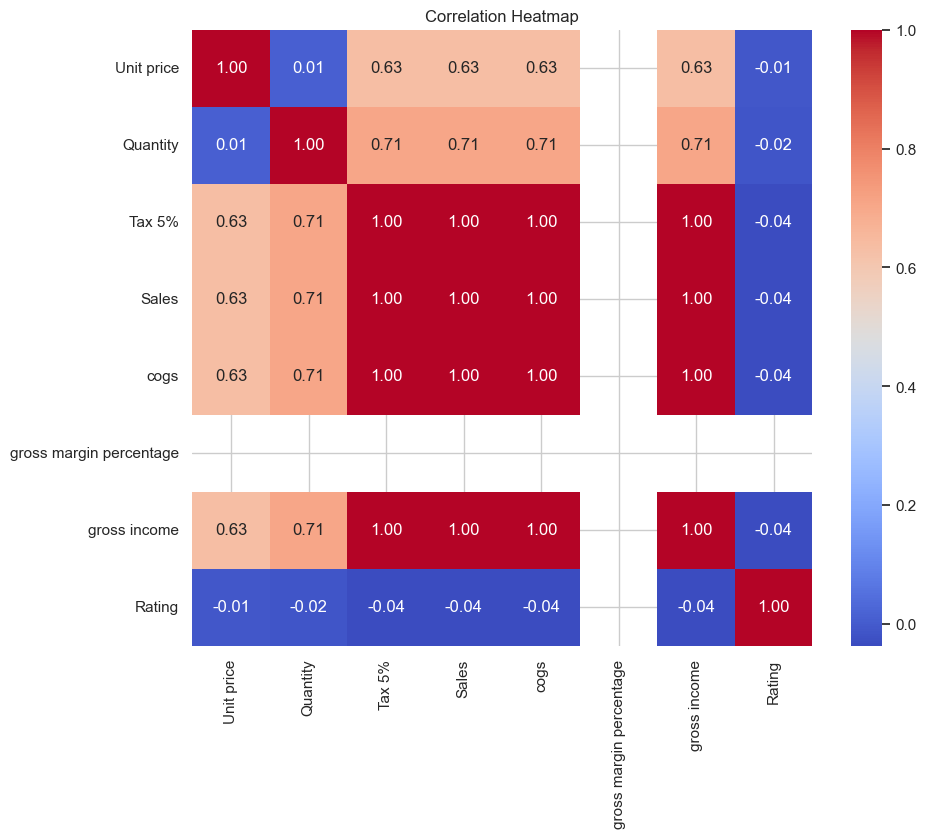

In [23]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.savefig('correlation heatmap.png', dpi=300)
plt.show()

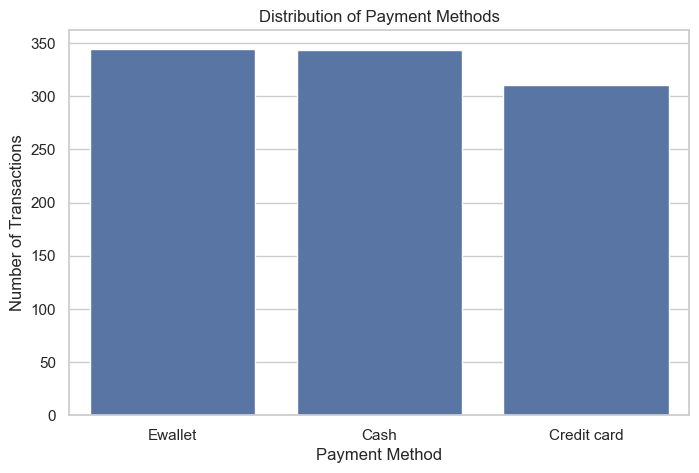

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Payment')

plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.savefig('Distribution by payment methods.png', dpi=300)
plt.show()